First of all, imports


In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.dataset import CocoSegDataset
from src.model import UNet


# Step 0 - Sanity check for dataset import

Checking image and mask shapes

In [5]:
dataset = CocoSegDataset(
    image_dir="../data/train/images",
    json_path="../data/train/train.json"
)

img, mask = dataset[0]
print(img.shape)   # (3, H, W)
print(mask.shape)  # (1, H, W)
print(mask.max())



torch.Size([3, 160, 160])
torch.Size([1, 160, 160])
tensor(1.)


# Step 1 - Overfitting 1 image
This step helps us to see and catch underlying technical mistakes. We overfit the model to confirm that the loss is converging to 0, and we do it for one image not to lose hours with the whole dataset

### Step 1.1 - Training our model

In [21]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print("Training is running, shouldn't take more than 1-2 minutes, even with CPU only ...")
!python ../src/train.py

True
NVIDIA GeForce RTX 3060 Laptop GPU
Training is running, shouldn't take more than 1-2 minutes, even with CPU only ...
Using device:  cuda
Epoch [1/200] | train_loss: 0.0000 | val_loss: 0.6356
Saved best model
Epoch [2/200] | train_loss: 0.0000 | val_loss: 0.5978
Saved best model
Epoch [3/200] | train_loss: 0.0000 | val_loss: 0.4588
Saved best model
Epoch [4/200] | train_loss: 0.0000 | val_loss: 0.0689
Saved best model
Epoch [5/200] | train_loss: 0.0000 | val_loss: 0.1320
Epoch [6/200] | train_loss: 0.0000 | val_loss: 0.0534
Saved best model
Epoch [7/200] | train_loss: 0.0000 | val_loss: 0.0777
Epoch [8/200] | train_loss: 0.0000 | val_loss: 0.0540
Epoch [9/200] | train_loss: 0.0000 | val_loss: 0.0507
Saved best model
Epoch [10/200] | train_loss: 0.0000 | val_loss: 0.0601
Epoch [11/200] | train_loss: 0.0000 | val_loss: 0.0531
Epoch [12/200] | train_loss: 0.0000 | val_loss: 0.0429
Saved best model
Epoch [13/200] | train_loss: 0.0000 | val_loss: 0.0406
Saved best model
Epoch [14/200] |

### Step 1.2 - Visualization of the data
In this step, we will take an actual look at what we just achieved.
First, let's see the original data from the dataset

In [22]:
image_dir = PROJECT_ROOT / "data" / "train" / "images"
json_path = PROJECT_ROOT / "data" / "train" / "train.json"

dataset = CocoSegDataset(
    image_dir = str(image_dir),
    json_path = str(json_path)
)

print ("Dataset size: ", len(dataset))

Dataset size:  3177


Now visualize it the first image (index=0)

Image shape:  torch.Size([3, 160, 160])
Mask shape:  torch.Size([1, 160, 160])
Image min/max,  0.0 1.0


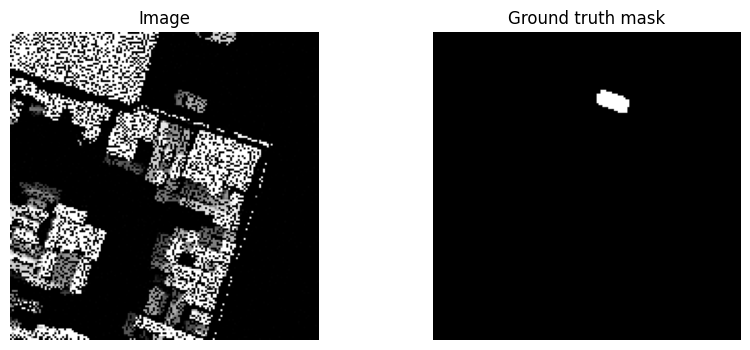

In [19]:
idx = 0

image, mask = dataset[idx]

# first, let's take a look at the image and mask attributes
print("Image shape: ", image.shape)
print("Mask shape: ", mask.shape)
print("Image min/max, ", image.min().item(), image.max().item())

# Plotting it
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image.permute(1,2,0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ground truth mask")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()

Overlaying the ground truth mask on the image

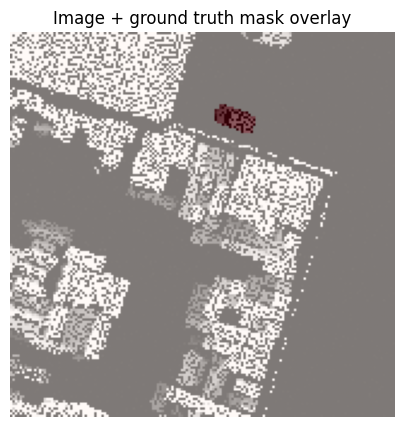

In [20]:
img_np = image.permute(1,2,0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(5,5))
plt.title("Image + ground truth mask overlay")
plt.imshow(img_np)
plt.imshow(mask_np, alpha=0.5, cmap="Reds")
plt.axis("off")
plt.show()

### Step 1.3 - Applying our model

First, let's load the model we trained in Step 1.1

In [23]:
# try CUDA if it's possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# loading our model to the device
model = UNet().to(device)

# loading our best model
checkpoint_path = PROJECT_ROOT / "checkpoints" / "best_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

# evaluation
model.eval()

print("Loaded model from: ", checkpoint_path)

### Step 1.4 - Predicting on the same image as above

In [25]:
with torch.no_grad():
    input_image = image.unsqueeze(0).to(device)
    logits = model(input_image)

    # we apply sigmoid here and not baked in the model.
    # The output of the model is raw logits.
    # This is because we use BCEWithLogitsLoss loss function. As the name suggests, it works with Logits, not with probabilities
    # Please refer to the PyTorch documentation: https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html
    probs = torch.sigmoid(logits)
    pred_mask = (probs > 0.5).float()


### Step 1.5 - Visualizing the raw image, ground truth and prediction

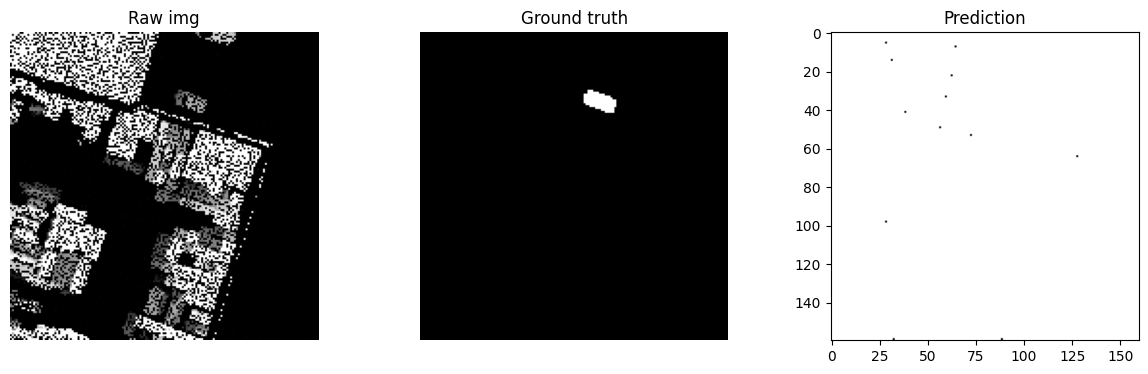

In [32]:
pred_np = pred_mask.squeeze().cpu().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Raw img")
plt.imshow(image.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground truth")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_np, cmap="gray")

plt.show()

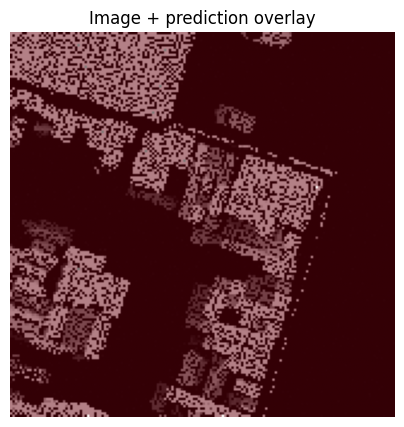

In [33]:
plt.figure(figsize=(5, 5))
plt.title("Image + prediction overlay")
plt.imshow(image.permute(1, 2, 0))
plt.imshow(pred_np, alpha=0.5, cmap="Reds")
plt.axis("off")
plt.show()

Looks pretty bad, right?

In [35]:
checkpoint_path = PROJECT_ROOT / "checkpoints" / "best_model.pth"

model = UNet().to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

criterion = torch.nn.BCEWithLogitsLoss()

image, mask = dataset[0]

with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))
    gt = mask.unsqueeze(0).to(device)

    loss = criterion(logits, gt)
    probs = torch.sigmoid(logits)

print("Notebook loss:", loss.item())
print("Logits min/max/mean:", logits.min().item(), logits.max().item(), logits.mean().item())
print("Probs min/max/mean:", probs.min().item(), probs.max().item(), probs.mean().item())

C:\Users\slajcho\AppData\Local\Temp\ipykernel_53264\1583710425.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_loca

Notebook loss: 0.00021693103190045804
Logits min/max/mean: -3352.678466796875 14.888402938842773 -931.2576293945312
Probs min/max/mean: 0.0 0.9999996423721313 0.005301514640450478
